# Численное решение уравнения теплопроводности

## 1. Задача

Решается уравнение:
$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + f(x,t), \quad x \in [0,1], t \in [0,T] \quad (1)
$$

**Будем работать со следующими входными данными данных:**

$\textbf{I.}$

- Начальное условие: $u_0(x) = x (x-1)$

- правая часть: $f(x,t) = e^{-\pi^2 t}(-\pi^2 x(x-1) - 2)$

- Точное решение: $u_{exact}(x,t) = e^{-\pi^2 t}x(x-1)$

$\textbf{II.}$

- Начальное условие: $u_0(x) = (x-1) \sin x$

- правая часть: $f(x,t) =  e^{-\pi^2 t}((x-1) (1-\pi^2)\sin x - 2\cos x)$

- Точное решение: $u_{exact}(x,t) = e^{-\pi^2 t} (x-1) \sin x$

$\textbf{III.}$
<!-- - Начальное условие: $u_0(x) = x(x-1)$ -->
- Начальное условие: $u_0(x) = \sin (\pi x)$

<!-- - правая часть: $f(x,t) = e^{-\pi^2 t}(-\pi^2 x(x-1) - 2)$ -->
- правая часть: $f(x,t) =  0$

<!-- - Точное решение: $u_{exact}(x,t) = e^{-\pi^2 t}x(x-1)$ -->
- Точное решение: $u_{exact}(x,t) = e^{-\pi^2 t} \sin (\pi x)$

#### $\textit{В данном ноутбуке мы будем решать задачу для исходных данных из}$ $\textbf{I}$ $\textit{случая}$

Точное решение $u_{exact}(x,t) = e^{-\pi^2 t} x (x-1)$ мы знаем из нашего отчета_3.pdf (поэтому и выбрали такую функцию $u(x, t)$, которая удовлетворяет краевым условиям задачи), поэтому точное решение подставляем в уравнение (1) и выражаем нашу функцию $f(x, t)$

А наше начальное условие $u_0(x) = x (x-1)$ - это просто $u_0(x) = u(x, 0)$, просто взяли наше точное решение $u_{exact}(x, t)$ и подставили $t = 0$

**Краевые/граничные условия:**
- $u(0,t) = 0$
- $u(1,t) = 0$

**Сетка смещена слева и справа:** 

$u(0,x_0) =  - u(0,x_1)$

$u(0,x_{M-1}) = - u(0,x_M)$

## 2. Исходные данные

Конечное время: $T = 1.0$

Пространственный шаг: $h = \frac{1}{M - 1}$

Временной шаг: $\tau = \frac{T}{N}$

### Тестовые кейсы

M-values = [5, 10, 20, 40, 80, 160]

1) key = 1, scheme = "explicit" (явная), M-values, formula for calcultaing N это $N = N_0 \cdot 2^i$, устойчивость при $\tau \leq h^2/2$

2) key = 1, scheme = "impicit" (неявная), M-values, formula for calcultaing N это $N = 2M_i^2$, безусловная устойчивость

## 3. Вычисление ошибки

Для каждой схемы вычисляется дискретная $L_2$-норма ошибки (корень из суммы квадратов разностей численного и аналитического решений), т.е.
$$
{error} = \|u_{числ} - u_{точн}\|_{L_2} = \sqrt{h \sum_{j=0}^M (u_{числ}(x_j,T) - u_{точн}(x_j,T))^2}
$$

Чем меньше ошибка, тем точнее схема.

### Как запускать программу

N, M – число отрезков разбиения по осям t и x

type_of_scheme $\in$ {1, 2} - если = 1 - явная схема, если = 2 - неявная схема

key $\in$ {1, 2, 3} - если = 1 - подсчет сходимости для явной схемы (M, N -> 2M, 2N), если = 2 - подсчет сходимости для неявной схемы (M, N -> 2M, 4N), если = 3 - чтобы показать безусловную устойчивость для неявной схемы (M = N)

В данном запуске ```./a.out 100 8 1 1``` значит, что N = 100, M = 8, type_of_scheme = 1, key = 1 - запуск явной схемы (для порядка сходимости)

В данном запуске ```./a.out 100 8 2 2``` значит, что N = 100, M = 8, type_of_scheme = 2, key = 2 - запуск неявной схемы (для порядка сходимости)

В данном запуске ```./a.out 100 8 2 3``` значит, что N = 100, M = 8, type_of_scheme = 2, key = 2 - запуск неявной схемы (для безусловной устойчивости схемы)

В случае явной схемы результаты хранятся в файл rate1.txt, в случае неявной схемы результаты хранятся в rate2.txt

Сначала пишется команда ```make clean``` (для очистки ненужных файлов типа .o)

После идет команда в терминале ```make```

И в конце пишем в терминале ```./a.out 100 8 1 1``` (к примеру)

Если что-то в программе изменилось, или есть необходимость удалить ненужные файлы, то нужно использовать команду make clean, после ```make``` и в конце ```./a.out 100 8 1 1` (к примеру)``

### Численное решение, точное решение и ошибка решения (график)

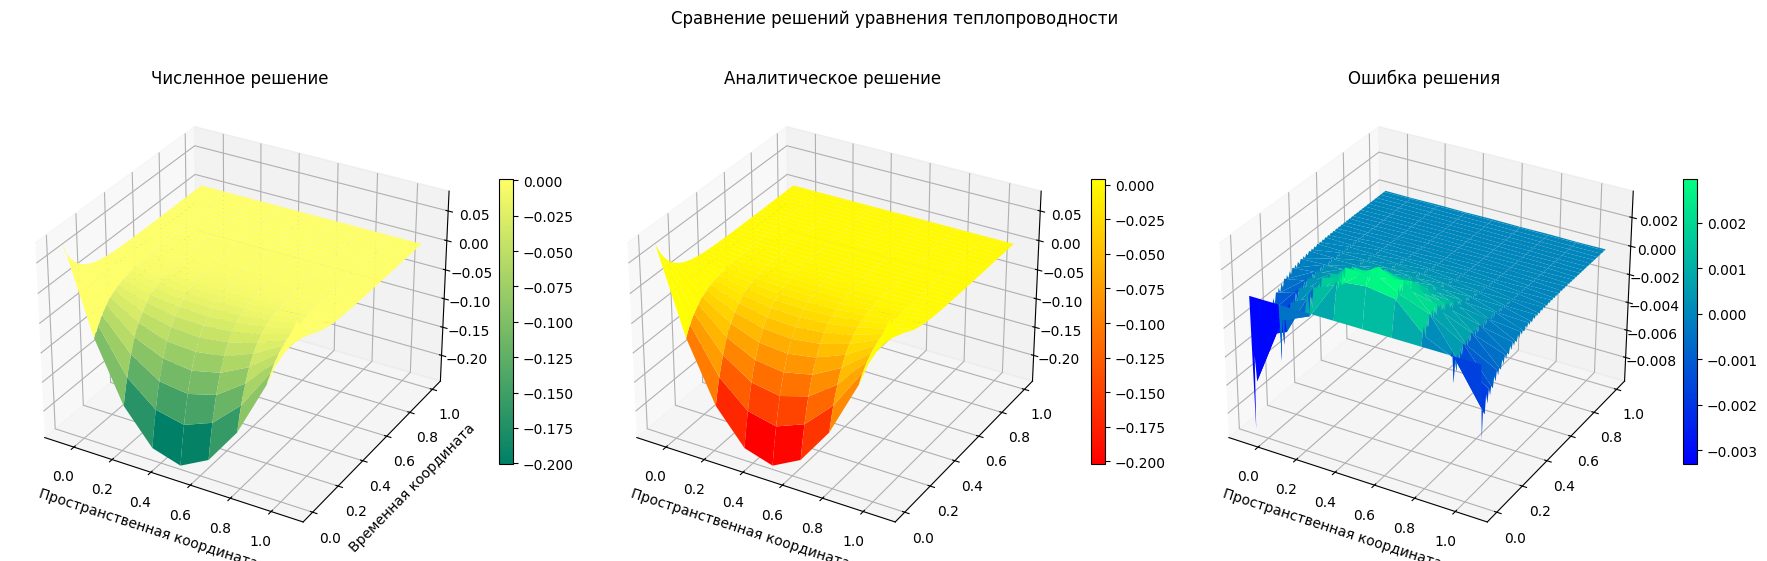

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

spatial_nodes = np.loadtxt('x.txt')
time_steps = np.loadtxt('t.txt')
numerical_solution = np.loadtxt('matrix.txt')

# Создание сетки для визуализации
x, t = np.meshgrid(spatial_nodes, time_steps)

# Аналитическое/точное решение
# analytical_solution = np.exp(-np.pi**2 * t) * x * (x - 1)
# analytical_solution = np.exp(-np.pi**2 * t) * np.sin(np.pi * x)
analytical_solution = np.exp(-np.pi**2 * t) * np.sin(x) * (x - 1)

solution_figure = plt.figure(figsize=(18, 6))

# График численного решения
num_sol_ax = solution_figure.add_subplot(131, projection='3d')
surface_plot = num_sol_ax.plot_surface(
    x, 
    t, 
    numerical_solution, 
    cmap='summer',
    edgecolor='none'
)
num_sol_ax.set_xlabel('Пространственная координата')
num_sol_ax.set_ylabel('Временная координата')
num_sol_ax.set_title('Численное решение')
solution_figure.colorbar(surface_plot, ax=num_sol_ax, shrink=0.5)

# График аналитического/точного решения
exact_sol_ax = solution_figure.add_subplot(132, projection='3d')
exact_plot = exact_sol_ax.plot_surface(
    x, 
    t, 
    analytical_solution, 
    cmap='autumn',
    edgecolor='none'
)
exact_sol_ax.set_xlabel('Пространственная координата')
exact_sol_ax.set_title('Аналитическое решение')
solution_figure.colorbar(exact_plot, ax=exact_sol_ax, shrink=0.5)

# График ошибки
error_ax = solution_figure.add_subplot(133, projection='3d')
error_plot = error_ax.plot_surface(
    x, 
    t, 
    numerical_solution - analytical_solution, # solution_error
    cmap='winter',
    edgecolor='none'
)
error_ax.set_xlabel('Пространственная координата')
error_ax.set_title('Ошибка решения')
solution_figure.colorbar(error_plot, ax=error_ax, shrink=0.5)

plt.tight_layout()
solution_figure.suptitle('Сравнение решений уравнения теплопроводности', y=1.02)
plt.savefig("3.png")
plt.show()

### Порядок сходимости схем

Проверим и покажем, что для явной схемы при увеличении M в 2 раза, N в 2 раза, т.е. $O(\tau^2 + h^2)$ :

$$
p = \frac{log(\frac{err2}{err1})}{log(\frac{\tau^2 + h_2^2}{\tau^2 + h_1^2})} \approx \frac{log(\frac{err2}{err1})}{log(\frac{M_2}{M_1})}
$$

Давайте для этого посчитаем показатель сходимости и покажем, что он будет приблизительно равен 2

In [3]:
scheme_1 = pd.read_csv("rate1.txt", sep=r'\s+')

scheme_1['Convergence rate'] = (np.log(scheme_1['Norma'].shift(1) / scheme_1['Norma'])) / (np.log(scheme_1['M'] / scheme_1['M'].shift(1))) 

scheme_1

,N,M,tau,h,Norma,Convergence rate
0,50000,5,2.000000e-05,0.250000,8.493055e-06,NaN
1,100000,10,1.000000e-05,0.111111,1.325187e-06,2.680088
2,200000,20,5.000000e-06,0.052632,2.851245e-07,2.216532
3,400000,40,2.500000e-06,0.025641,6.657285e-08,2.098586
4,800000,80,1.250000e-06,0.012658,1.591451e-08,2.064591
5,1600000,160,6.250000e-07,0.006289,3.788421e-09,2.070674


В данной таблице мы видим в случае запуска ```./a.out 100 8 1 1```, что в столбце "Convergence rate" показатель сходимости приблизительно равен 2

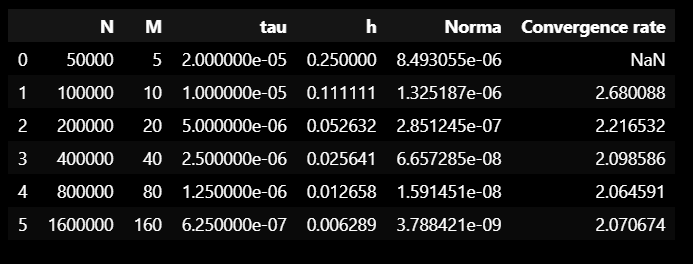

Проверим и покажем, что для неявной схемы при увеличении M в 2 раза, N в 4 раза, т.е. $O(\tau + h^2)$ :

$$
p = \frac{log(\frac{err2}{err1})}{log(\frac{\tau + h_2^2}{\tau + h_1^2})} \approx \frac{log(\frac{err2}{err1})}{log(\frac{M_2}{M_1})}
$$

Давайте для этого посчитаем показатель сходимости и покажем, что он будет приблизительно равен 2

In [2]:
scheme_2 = pd.read_csv("rate2.txt", sep=r'\s+')

scheme_2['Convergence rate'] = (np.log(scheme_2['Norma'].shift(1) / scheme_2['Norma'])) / (np.log(scheme_2['M'] / scheme_2['M'].shift(1))) 

scheme_2

,N,M,tau,h,Norma,Convergence rate
0,500,500,0.002000,0.002004,9.085808e-07,NaN
1,1000,1000,0.001000,0.001001,4.462252e-07,1.025843
2,2000,2000,0.000500,0.000500,2.211180e-07,1.012956
3,4000,4000,0.000250,0.000250,1.100631e-07,1.006486
4,8000,8000,0.000125,0.000125,5.490783e-08,1.003247
5,16000,16000,0.000063,0.000063,2.742289e-08,1.001631


В данной таблице в случае запуска ```./a.out 100 8 2 2``` мы видим, что в столбце "Convergence rate" показатель сходимости приблизительно равен 2

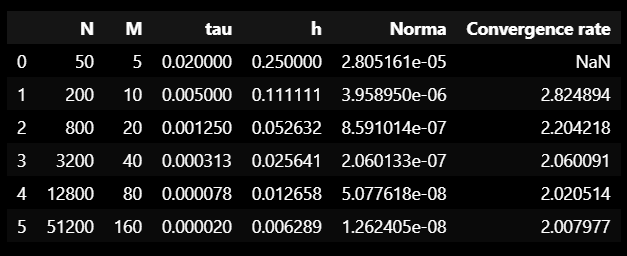

В данной таблице в случае запуска ```./a.out 100 8 2 3``` мы видим, что в столбце "Convergence rate" показатель сходимости начинает уменьшаться (показатель уменьшается с 2.36 до 1.15). Мы показали безусловную устойчивость для неявной схемы (и в данном случае неявная схема менее хорошая хорошая, чем явная схема). В данном случае мы не видим порядка 2, потому что если будем увеличивать M и N в 2 раза (M=N), тонепонятно какой порядок сходимости (нельзя проследить четко, но при больших M=N сходимость к 1).

Выбор шагов при \( N = M \)

Шаги определяются как $\tau = \frac{1}{N}, \ h = \frac{1}{M - 1} \approx \frac{1}{M}$ при больших $M$

При N = M: $\tau \approx \frac{1}{M} \sim h$

Поведение погрешности при $\tau \sim h$

Подставляя $\tau \sim h$ в общую погрешность:
\begin{equation}
    \text{error} = O(\tau + h^2) = O(h + h^2)
\end{equation}

При $h \to 0$:
$h^2$ становится пренебрежимо малым по сравнению с $h$
Погрешность упрощается до:
\begin{equation}
    \text{error} \approx O(h)
\end{equation}

Показатель сходимости $p$ вычисляется как:
\begin{equation}
    p = \frac{\log(\text{error}_1 / \text{error}_2)}{\log(h_1 / h_2)}
\end{equation}

Если $\text{error} \approx C \cdot h$, то:
\begin{equation}
    \frac{\text{error}_1}{\text{error}_2} \approx \frac{h_1}{h_2} \quad \Rightarrow \quad p \approx \frac{\log(h_1 / h_2)}{\log(h_1 / h_2)} = 1
\end{equation}

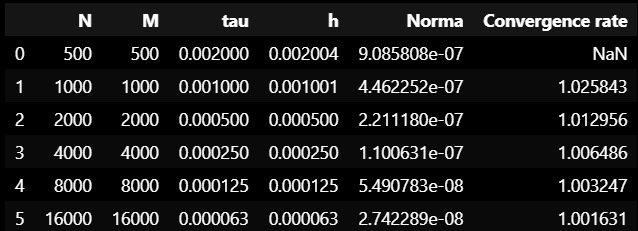

### Ниже представлен следующий код для иллюстрации экспериментов (добавил этот код для пункта 4 из требования в чате телеграмма Проверка ЭВМ)

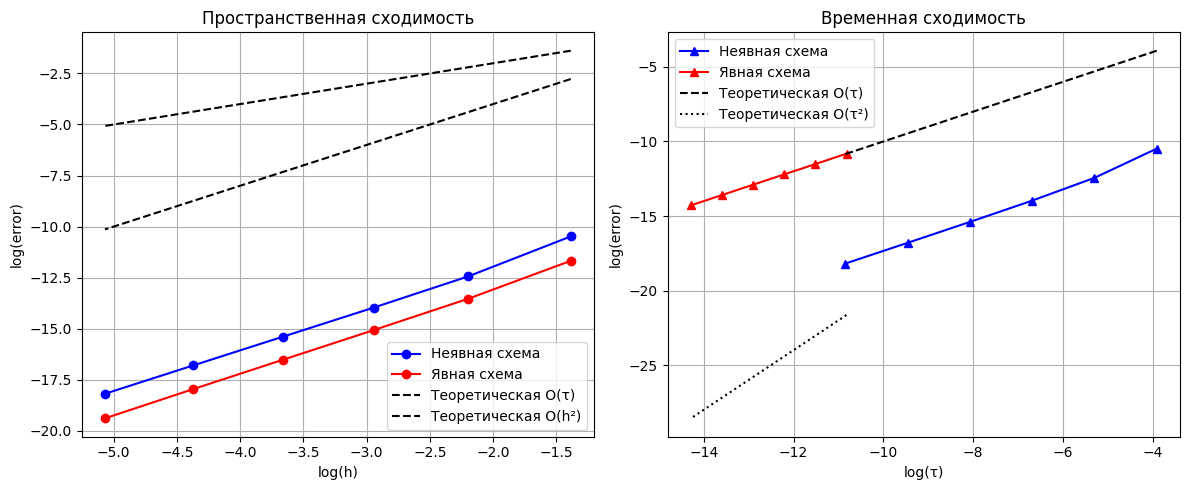

In [5]:
scheme_1_log_h = np.log(scheme_1['h'])
scheme_1_log_error = np.log(scheme_1['Norma'])
scheme_1_log_tau = np.log(scheme_1['tau'])

scheme_2_log_h = np.log(scheme_2['h'])
scheme_2_log_error = np.log(scheme_2['Norma'])
scheme_2_log_tau = np.log(scheme_2['tau'])

plt.figure(figsize=(12, 5))

# Сходимость по x
plt.subplot(121)
plt.plot(scheme_2_log_h, scheme_2_log_error, 'bo-', label='Неявная схема')
plt.plot(scheme_1_log_h, scheme_1_log_error, 'ro-', label='Явная схема')
plt.plot(scheme_2_log_h, scheme_2_log_h, 'k--', label='Теоретическая O(τ)')
plt.plot(scheme_2_log_h, 2 * scheme_2_log_h, 'k--', label='Теоретическая O(h²)')
plt.xlabel('log(h)')
plt.ylabel('log(error)')
plt.title('Пространственная сходимость')
plt.legend()
plt.grid(True)

# Сходимость по t
plt.subplot(122)
plt.plot(scheme_2_log_tau, scheme_2_log_error, 'b^-', label='Неявная схема')
plt.plot(scheme_1_log_tau, scheme_1_log_tau, 'r^-', label='Явная схема')
plt.plot(scheme_2_log_tau, scheme_2_log_tau, 'k--', label='Теоретическая O(τ)')
plt.plot(scheme_1_log_tau, 2*scheme_1_log_tau, 'k:', label='Теоретическая O(τ²)')
plt.xlabel('log(τ)')
plt.ylabel('log(error)')
plt.title('Временная сходимость')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#plt.plot(scheme_2['error'][1:], scheme_2['Convergence rate'])